# Introduction to Linear Regression

# The linear function

Under the hood Linear Regression model uses the linear function.

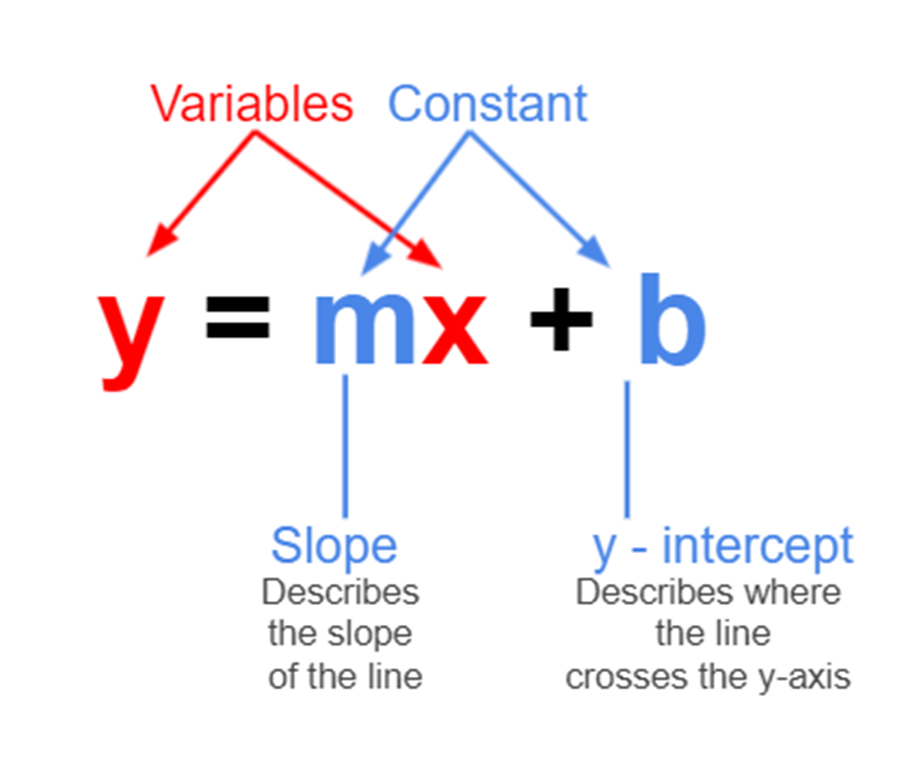

A linear function is a mathematical function that models a relationship between two variables in such a way that the output is directly proportional to the input. In simpler terms, if you graph a linear function, it will be a straight line.

Here, m is the slope of the line, which determines how steep the line is, and b is the y-intercept, which is where the line crosses the y-axis.

The slope m tells you how much y changes for a one-unit change in x. The y-intercept b is the value of y when x=0.

**Note**: Elsewhere, you may see the above formula written as $y = mx + c$. The choice between b and c is purely a matter of convention and doesn't impact the mathematical principles involved.

Some real life examples of when a linear function may be used:

- For a phone billing plan with a set monthly fee of £20 and a rate of 5p per minute, your monthly cost y for x minutes would be $y=0.05x+20$.

- A movie streaming service charges a monthly fee of £4.50 and an additional fee of £0.35 for every movie downloaded. The total monthly fee is represented by the linear function $y = 0.35x + 4.50$, where x is the number of movies downloaded in a month.

Example:
    
In this scenario, $y = 3x+1$.

Below, we have a list, x, that contains some elements, and an empty list y.

In [1]:
# import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
x = [0, 1, 2, 3]
y = []

We can create a for loop to iterate over each element in the list x. In each iteration, 'value' will take on one of the values in x.

In [3]:
for value in x:
    a = value * 3 + 1
    y.append(a)
    
y

[1, 4, 7, 10]

##### Task 1: find the y value for each x value.

The x values are [0, 2, 4, 6, 8, 10], the slope is m=5, and the y-intercept is c=3.

In [4]:
## TASK 1: My answer
x = [0,2,4,6,8,10]
y = []

for value in x:
    a = value * 5 + 3
    y.append(a)

print(y)

[3, 13, 23, 33, 43, 53]


When we plot the values from the example above, we can see that we get a straight line. This is what defines the linear function - we know that whenever we use it, we will get a straight line as an output.

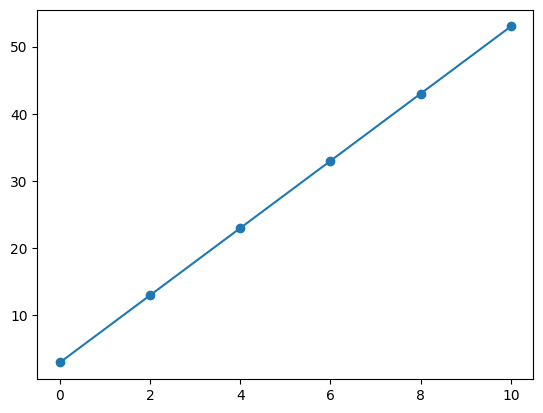

In [5]:
fig, ax = plt.subplots()
ax.plot(x, y, "-o")

How would we adapt the function if we wanted a curved line?

 **Answer**
 - You would square the value

---

So far, we have established thay y and x are our variables, while m is the slope and b is where the line intercepts the y axis.

But what will happen if we change the constants? Follow [this link](https://phet.colorado.edu/sims/html/least-squares-regression/latest/least-squares-regression_en.html) and see for yourself. You'll also be able to add a line of best fit and the residuals (we will explore these concepts in greater detail later on).


<br>
<br>
<br>

# Simple Linear Regression vs Multiple Linear Regression

The difference between linear regression and multiple linear regression is that linear regression examines the relationship between one predictor and an outcome, while multiple regression delves into how several predictors influence that outcome.

With linear regression, we are just looking at the relationship between two variables - the independent and dependent variables. For example, predicting someone's height based off their weight.

However, with multiple linear regression, we are still predicting one dependent variable but are using multiple independent variables to do so. This will give us multiple slopes, and while the linear regression slope just looks like a 2D line, for multiple linear regression we are looking at a three-dimensional plane. Instead of predicting someone's height based off their weight, we may also have age, diet, or activity level as another independent variable.

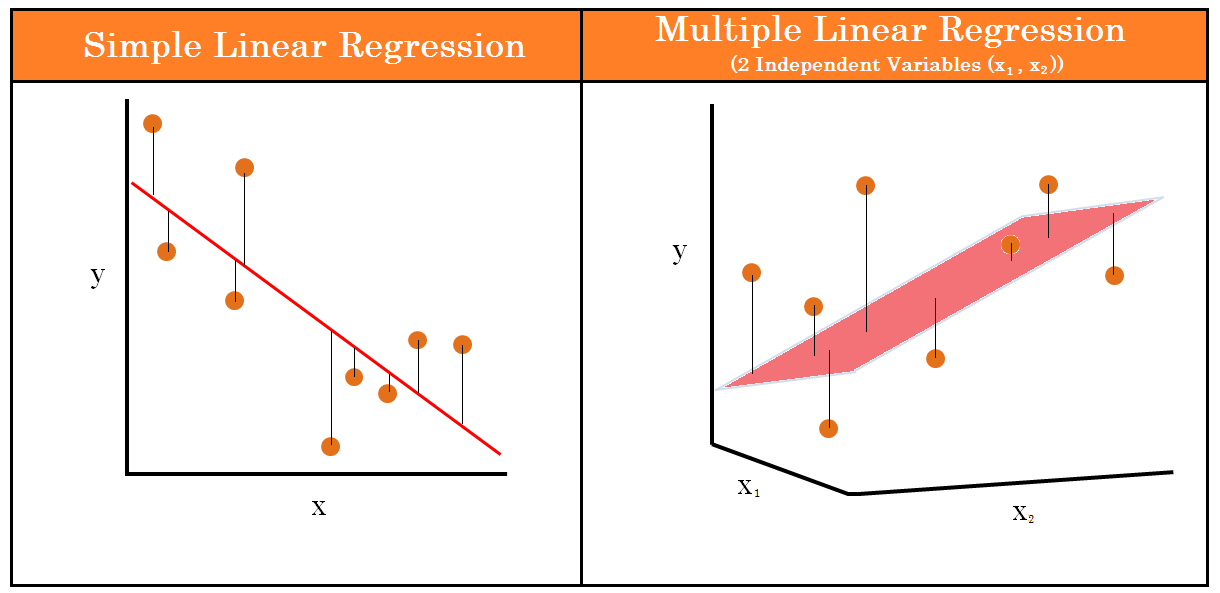

For the diagram below, you can see how multiple linear regression would be displayed on a 3D graph. Here, we are predicting MPG (y axis) using weight (x axis) and horsepower (z axis) as predictors.

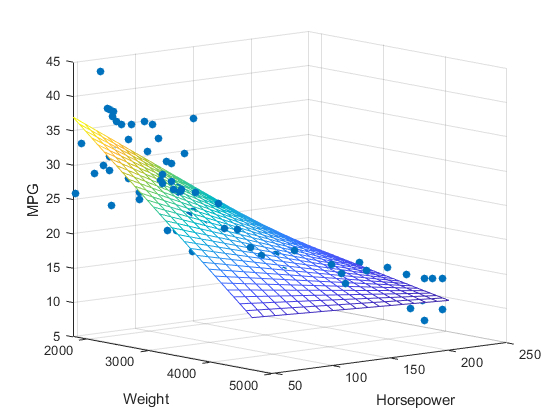

Below, you can see the equations for a simple linear regression and a multiple linear regression. The y will always be the dependent variable and the x will always be the independent variables, however many there are.

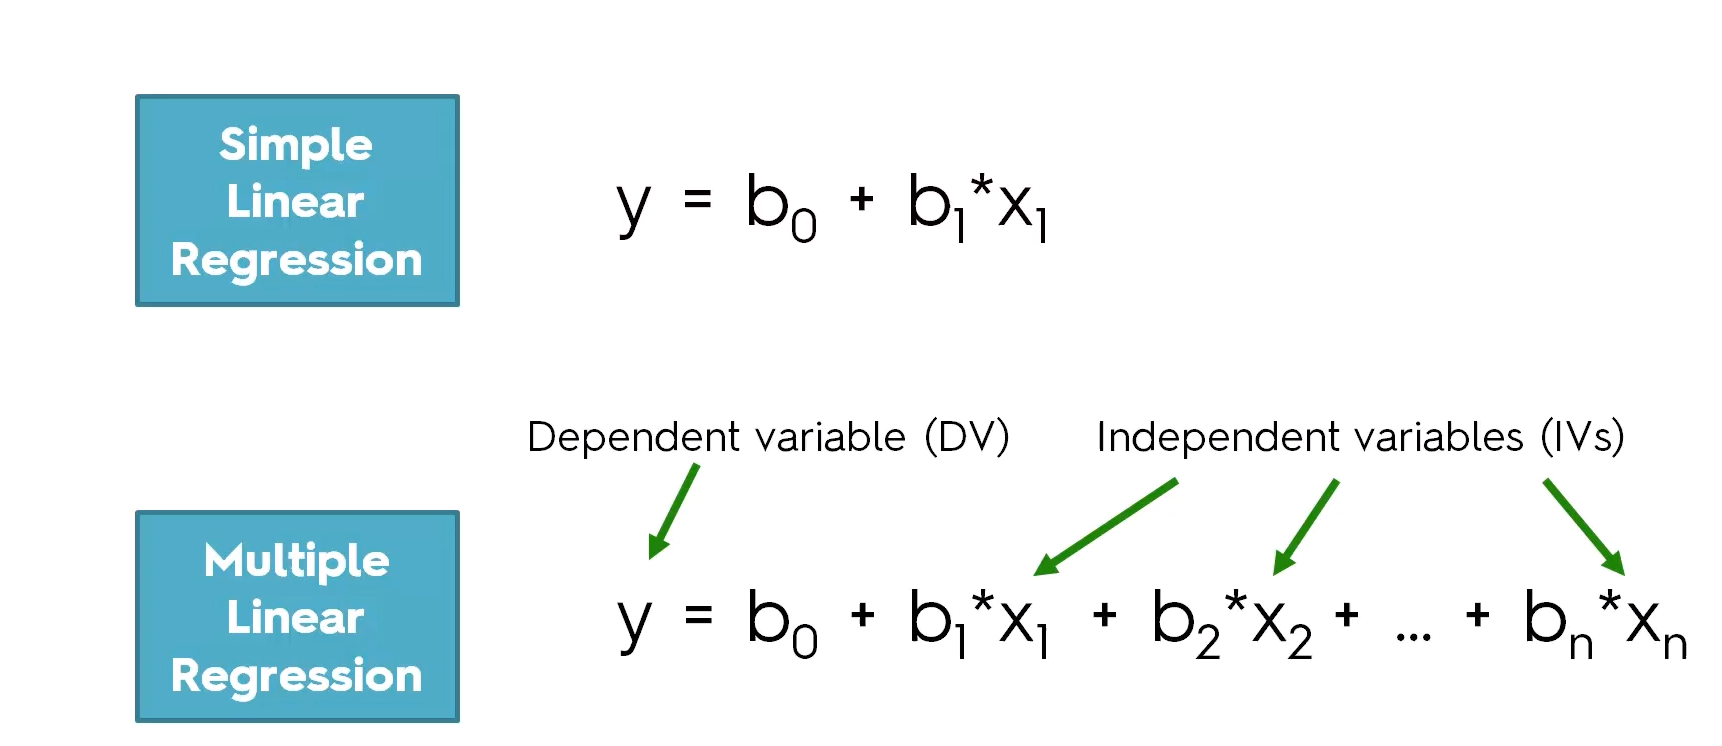

# Steps to build, test and validate a model

Now we are ready to build our first model! These are the steps we shall be following:

1. Investigate/clean the data
2. Define the target and features
3. Train-test split
4. Create the model
5. Evaluate the model
6. Validate the model

## Investigate/clean the data

We will be using the diamonds dataset from seaborn.

The dataset has the following columns:

- carat: The weight of the diamond, measured in carats.
- cut: The quality of the diamond cut, with levels including Fair, Good, Very Good, Premium, and Ideal.
- color: Diamond colour, from J (worst) to D (best).
- clarity: A measurement of how clear the diamond is, with levels like I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best).
- depth: The height of a diamond, measured from the culet to the table, as a percentage of its average girdle diameter.
- table: The width of the diamond's table expressed as a percentage of its average diameter.
- price: The price of the diamond in US dollars.
- x: Length of the diamond in mm.
- y: Width of the diamond in mm.
- z: Depth of the diamond in mm.

In [7]:
# sns.get_dataset_names()

In [8]:
diamonds = sns.load_dataset('diamonds')

# or uncomment the line below and change the file path
# diamonds = pd.read_csv('data/diamonds.csv')

diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Let's use .info() to provide a summary of the data. In particular, we want to make sure there are no null values as our model won't work otherwise!

In [9]:
diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


## Define the target and the features

Next, we need to define the target and feature variables - we have to do some preprocessing before the data is ready to use in the model.

- **Target** is a dependent numerical variable that have to be predicted. Conventionlly this is denoted as `y`. For our example, this will be price.
- **Features** are predictors or the independent variables that might influence the target value, denoted as `X`. For our example, this wil be all other numerical features in the dataset.

In [10]:
# define the features
X = diamonds[['carat', 'depth', 'table', 'x', 'y', 'z']]
# define the target
y = diamonds['price']

As a side note, it's worth pointing out that X is in the format of a dataframe, while y is a Series.

The code below will create a scatterplot for each predictor with price, so we can see the relationship between each of them.

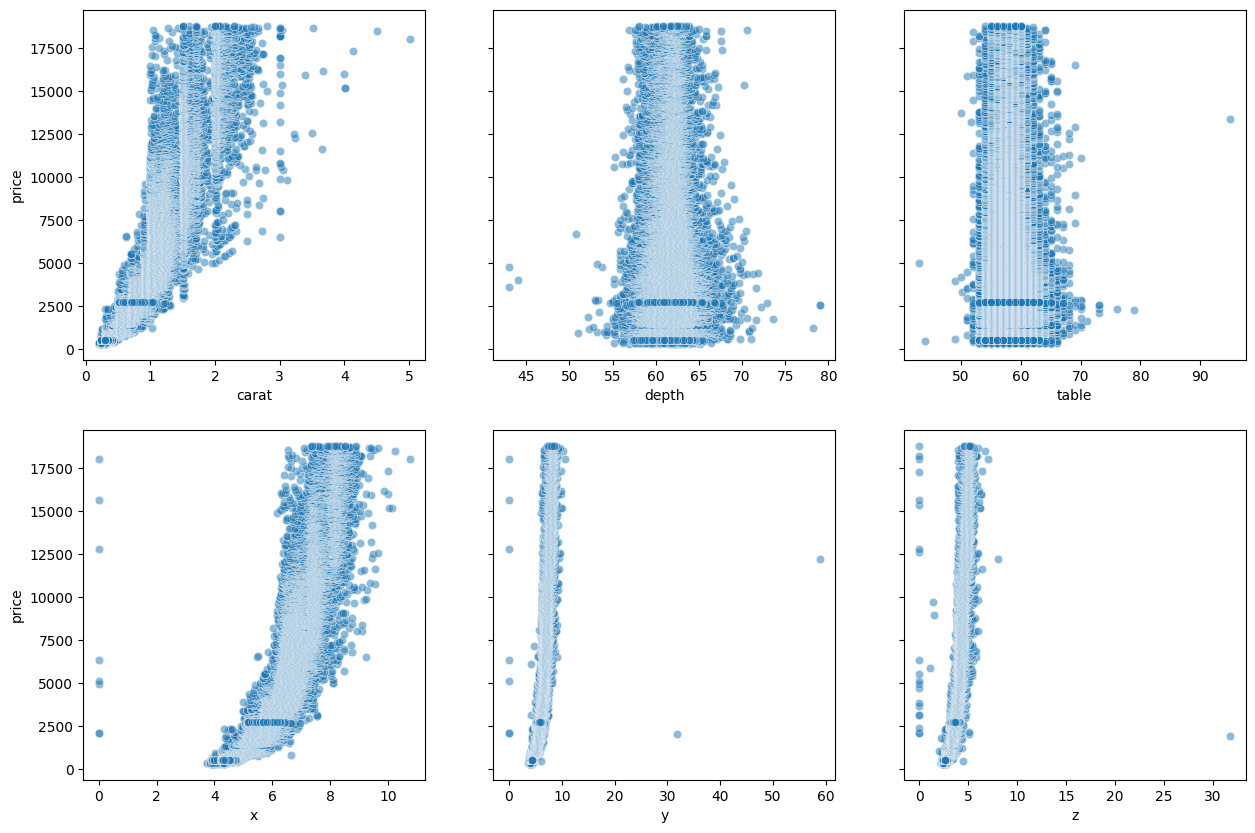

In [11]:
# Create a 2x3 grid of subplots with a shared y-axis.
fig, axes = plt.subplots(2, 3, figsize = (15,10), 
                         sharey = True)

# Define the features (variables) we want to plot.
# The array is structured to match the 2x3 grid of subplots.
features = np.array([['carat', 'depth', 'table'], 
                     ['x', 'y', 'z']])


# Loop through each subplot row in the grid (indexed by m)
for m, ax in enumerate(axes): 
    # Loop through each subplot column in the grid (indexed by n)
    for n, subax in enumerate(ax):
        # Create a scatter plot in the corresponding subplot.
        sns.scatterplot(
            data = diamonds, 
            x = features[m][n], 
            y = 'price', 
            ax = subax, 
            alpha = 0.5
            )
  

From the scatterplots, we can see there is a strong relationship between price and carat. Price with x is also relatively strong. Depth, table, y and z have weak correlations with price.

Let's view the correlation metrics of each of the numeric values in the diamonds dataset. This visualises the above but in numerical format.

In [14]:
diamonds_numerical = diamonds.select_dtypes(include=['float64', 'int64'])
diamonds_numerical.corr()

,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


## Train - Test split

Now is the moment we will be splitting our data.

We can test the quality of our model by splitting the dataset into 2 parts:
- the training set: contains the main part of the data (80%)
- the test set: contains the rest of the data from the whole (20%)


The train set is used to train the model - this means finding the model that best approximates the training set. This is the most computationally intensive process.

The test set is used to predict the values - predict the target value for an instance by plugging features into the trained model. This process is computationally cheap.

Then we can compare the train and test score.



<br>

*Note:*

An 80:20 split is the most common way of spltting the data, however, anything from 90:10 to 50:50 is used in practice. There's no particular guidance on what you should use - the 80:20 split comes from the [Pareto Principle](https://www.investopedia.com/terms/p/paretoprinciple.asp), but this is just a rule of thumb. If the dataset is relatively small, you could have a 70:30 split as this might provide a more representative test set, but you will have a slightly smaller training sample. If the model is particularly complex, you could have an 80:20 split to provide more training data and in turn help the model generalise better.


When in doubt - just use the 80:20 split.

The scikit-Learn library provides us with a function named train_test_split().  This function helps us to divide the dataset into two subsets for model training and model testing.

We will become very acquainted with scikit-learn over the course of the module - we will use it for all of our 'shallow' algorithms. (Algorithms that don't have hidden layers, for example neural networks)

This function will shuffle all the dataset rows randomly, and then it will perform the splitting.
The function returns 4 outputs in the following order:
- a dataset with the features for training
- a dataset with the features for testing
- the target values for training (the model knows them)
- the target values for testing (the model doesn't know them)

In [15]:
# import train_test_split from the sklearn library
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2023)
X_train, X_test, y_train, y_test

(       carat  depth  table     x     y     z
 48240   0.86   63.2   61.0  6.05  5.97  3.79
 20250   1.51   65.0   59.0  6.99  7.07  4.57
 34895   0.33   61.9   55.0  4.44  4.48  2.76
 33899   0.30   62.0   55.0  4.31  4.27  2.66
 29466   0.32   62.0   55.0  4.36  4.38  2.71
 ...      ...    ...    ...   ...   ...   ...
 38620   0.31   63.1   57.0  4.27  4.32  2.71
 38817   0.39   62.5   54.0  4.70  4.67  2.92
 51895   0.73   62.8   55.0  5.73  5.76  3.61
 47558   0.70   62.3   55.0  5.67  5.72  3.55
 22041   0.31   62.8   55.0  4.35  4.31  2.72
 
 [43152 rows x 6 columns],
        carat  depth  table     x     y     z
 25388   2.02   56.5   61.0  8.33  8.37  4.72
 15396   1.12   61.6   56.0  6.69  6.71  4.13
 35778   0.32   62.1   54.0  4.41  4.42  2.74
 3379    0.31   61.3   58.0  4.34  4.37  2.67
 45160   0.50   60.7   61.0  5.12  5.09  3.10
 ...      ...    ...    ...   ...   ...   ...
 36438   0.31   61.7   55.0  4.40  4.35  2.70
 50067   0.70   61.6   56.0  5.69  5.71  3.51
 2960

To summarise the code block above:

`X` and `y` are our features and labels. `X` contains the input variables, and `y` contains the output variable.

`test_size = 0.2` specifies that we are setting aside 20% of the data for testing, while the remaining data will be used for training.

`random_state = 2023` is for reproducibility - setting a random state ensures that the random data shuffling will produce the same result each time you run the code.

In [17]:
y_train.head()

48240    1950
20250    8681
34895     880
33899     844
29466     702
Name: price, dtype: int64

In [18]:
y_test.head()

25388    14080
15396     6168
35778      912
3379       408
45160     1654
Name: price, dtype: int64

##### Task 2: 
- Investigate the cars dataset(check for missing values and data types)
- Identify an appropriate target for your model. Identify a few features that could be good predictors for your target(create X_cars and y_cars, to avoid overwriting previous code).
- Split the dataset into a train set and a test set. Assign the output of splitting to the variables X_train_cars, X_test_cars, y_train_cars, y_test_cars.  

## Model Creation

Now we can begin to create the model. First of all, we will need to import the class `LinearRegression` from the `sklearn.linear_model` library.

In [19]:
from sklearn.linear_model import LinearRegression

After, we will create just an empty model which only contains the core model and nothing else.

In [20]:
# create the model
model = LinearRegression()

The bare bones of our model have been created now. The second step is to fit the model to the data, and to do this we will be using the function `fit`.

Inside this function, we will input the features (X_train) and the corresponding target variables (y_train).

When we run this code, what the model does it use the feature and target data to learn the best possible linear relationship that predicts the target y_train based on the features X_train.

In [21]:
# fit the model to the training data
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


We can also view the slope by using `model.coef_`. This attribute holds the values of the coefficients (also known as weights or parameters) that the model has learned for each feature variable during the training process.

In the equation $y=mx+c$, m is the coefficient for the feature x. As we have six features, our equation will look more like

$$y = m_{1}.x_{1} + m_{2}.x_{2}+ m_{3}.x_{3}+ m_{4}.x_{4}+ m_{5}.x_{5}+ m_{6}.x_{6} + c$$

Running `model.coef_` gives us our 6 coefficients, each telling you the 'impact' of those features on the target variable. These correspond to carat, depth, table, x, y and z.

In [22]:
# the slope
model.coef_

array([10588.39978392,  -205.29927532,  -102.52085196, -1295.18511393,
          60.52687981,    76.98527858])

We can also view the intercept of the model using `model.intercept`. This gies you the value of the intercept, c, in our linear model equation. 

The intercept helps you to calibrate the model to our data, shifting the regression line up or down to best fit the distribution of points.

In [23]:
# the intercept
model.intercept_

np.float64(20854.581966993115)

We can plug in these values into our linear equation, as we have the coefficient (m), the intercept (c), and we can use the first row of values in the diamonds dataset as our x values.

In [24]:
# view the first row of the data:
diamonds.head(2)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31


In [25]:
# the linear function:
price = (10588.39978392 * 0.23) - (205.29927532 * 61.5) - (102.52085196 * 55) - (1295.18511393 * 3.95) + (60.52687981 * 3.98) + (76.98527858 * 2.43) + 20854.581966992955 

In [26]:
price

337.3516358842571

Our model has calculated the price as £337.35; however, in the dataset we can see the actual price is £326. We're not too far off, but not exact! We will look at how we can improve our model further down the line.

Thankfully, we don't need to calculate the linear function for each row of the X_test dataset by hand. We can use our trained linear regression model to make predictions on the test dataset, and returns an array of these predicted values.

In [27]:
# make predictions on the new data
predicted_prices = model.predict(X_test)

In [28]:
predicted_prices

array([14471.05700557,  6385.28280772,   724.36101459, ...,
        1031.6518535 , 10287.9684007 ,  2322.12556366], shape=(10788,))

##### Task 3: 
- Create and train a model using the cars train and test datasets. Assign the model to a variable named car_model.

<br>
<br>
<br>
<br>

## Evaluate the model

Now that we understand some of the theory behind $R^2$, we can implement this on our model for the diamonds dataset.

In [29]:
# R_squared for training dataset
model.score(X_train, y_train)

0.8582959744536787

In [30]:
# R_squared for test dataset
model.score(X_test, y_test)

0.8628896236791446

So, we have a $R^2 $ score of 85.8% for the training dataset and 86.3% for the test dataset. As our scores are above 0.7, we could say that the model has good fit to the data. Also, as the scores are quite similar, our model is performing consistently across both datasets. it's not overfitting to the training data, which would be indicated by a high training score and a lower test score.

In [32]:
# predicting the prices for the diamonds from the test dataset
y_predicted = model.predict(X_test)
y_predicted

array([14471.05700557,  6385.28280772,   724.36101459, ...,
        1031.6518535 , 10287.9684007 ,  2322.12556366], shape=(10788,))

### Errors

https://phet.colorado.edu/sims/html/least-squares-regression/latest/least-squares-regression_en.html

Besides the score(coefficient of determination), we have another metric based on the model errors. The error metric quantifies how inaccurate our predictions were compared to the actual values. We can compute it by calculating the difference between each predicted and actual value and then averaging these differences.

What we will do now is create a dataframe where we will store the vales for `y_test`. We will then add the `y_predicted` values to the dataframe, stored in a column with the same name. Then, we compute the absolute error between the predicted values and the actual values. Note it is the **absolute** error - it is the magnitude of the difference between the actual and predicted values, irrespective of their sign.

In [33]:
# create new df
test_values = pd.DataFrame(y_test)

In [34]:
# add y_predicted values to dataframe
test_values['y_predicted'] = y_predicted
test_values

,price,y_predicted
25388,14080,14471.057006
15396,6168,6385.282808
35778,912,724.361015
3379,408,454.880674
45160,1654,1348.732276
...,...,...
36438,942,603.711433
50067,2202,3125.082260
29605,706,1031.651854
19050,7835,10287.968401


In [35]:
#  calculating the difference between each predicted and actual value
test_values['error'] = np.absolute(test_values['y_predicted'] - test_values['price'])

In [36]:
test_values

,price,y_predicted,error
25388,14080,14471.057006,391.057006
15396,6168,6385.282808,217.282808
35778,912,724.361015,187.638985
3379,408,454.880674,46.880674
45160,1654,1348.732276,305.267724
...,...,...,...
36438,942,603.711433,338.288567
50067,2202,3125.082260,923.082260
29605,706,1031.651854,325.651854
19050,7835,10287.968401,2452.968401


Finally, we compute the mean of the absolute errors.

In [37]:
# calculating MAE
test_values['error'].mean()

np.float64(880.7236831894921)

This metric is called the **mean absolute error** or **MAE**.

So we have a figure of 880.72 - but what does that mean?

MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. This figuremeans that on average, our model's predictions are off by about 880 units, whatever those units might be. However, the context of the data is important. If we were predicting house prices and the price ranged from £100,000 to £1,000,000, then a MAE score of 880 would be seen as a very good score. If we were predicting the prices of inexpensive items like books which ranged from £5 to £50, then a MAE score of 880 would be terrible and we've probably gone very wrong somewhere!

In the context of the diamonds dataset, it means that, on average, our model's predictions on diamond prices are off by £880.
Given the diverse price range in the dataset, a MAE of £880 can be seen as a moderate error. For cheaper diamonds (e.g., those in the lower quartiles), an error of £880 could be quite significant. For more expensive diamonds (e.g., in the higher quartiles), this error might be less impactful relative to the overall price.

We can also implement MAE in scikit-learn.

In [39]:
# The mean absolute error or MAE
from sklearn.metrics import mean_absolute_error

In [40]:
# calculating MAE using sklearn
mean_absolute_error(y_test, y_predicted)

880.7236831894921

##### MSE

To see if we have too big errors, we can "penalise" the predicted values further away from the actual value. We can do this by squaring the error values and then take their mean. Thus, a low error metric means that the difference between the predicted list of prices and the actual price values is small, while a high error metric means the difference between the predict and the real value is big. It also means that larger errors have a disproportionately large impact on the MSE.

In [41]:
# The mean squared error or MSE
from sklearn.metrics import mean_squared_error

In [42]:
mean_squared_error(y_test, y_predicted)

2167131.372700222

This means that for our dataset, we have the squared difference between the actual diamond prices and the predicted prices by your model is 2,167,131 (in squared pounds).
The problem with this metric is that it isn't really interpretable. Pounds squared isn't very useful to us, so we need to get back to something which we *can* interpret but still keep the penalisation of the outliers. This is why the root mean squared error, or RMSE, exists. RMSE is a quadratic scoring rule that also measures the average magnitude of the error.

##### RMSE

In [43]:
# The root mean squared error or RMSE

In [44]:
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_test, y_predicted)

1472.1179887156538

#### MAE vs RMSE

- **Units of Interest:** Both MAE and RMSE express the average model prediction error in the original units of the variable of interest. For example, if we're predicting diamond price, both the MSE and RMSE wil be in terms of currency. For the cars dataset, it will be in mpg.

- **Range:** Both the MAE and RMSE can range from 0 to $+∞$. An MAE or RMSE of 0 would indicate a perfect fit to the data. In reality, a value of 0 is almost impossible, but closer the value is to 0, the better the model is at predictions.

- **Orientation:** Both metrics are negatively-oriented, meaning that lower values are indicative of a better model fit. This is because they both measure 'error', and a smaller error implies a better predictive model.

BUT

- RMSE gives a relatively high weight to large errors. This means RMSE might be more useful when large errors are undesirable.

[This website](https://proclusacademy.com/blog/explainer/regression-metrics-you-must-know/) gives a good summary of MAE, MSE and RMSE.

##### Task 4: Evaluate the model based on the car dataset. Find out the R-squared, the MAE, MSE and RMSE scores. What did you notice?

## Model validation

At this point, we have defined the target and features, created the model and evaluated the model by computing the errors. Now, we need to validate the model. When we randomly split our dataset into train and test datasets, we may get a test sample containing a lot of noise (outliers) that will worsen the model. But the sample may have some very relevant data that will make the model perform better.

We need a model that can generalize well on the new data.

### Check for underfitting and overfitting

When we build models, it's essential to be aware of two common pitfalls: overfitting and underfitting. 

**Overfitting** happens when our model learns the training data too closely, even its noise. While it might perform brilliantly on this training data, it can struggle with new data because it's learned too many specifics and not enough general patterns.

On the flip side, **underfitting** is when our model is too simple, missing out on important patterns altogether. This causes it to perform poorly on both training and new data. 

So, our goal is to find the sweet spot between the two. A good model should capture the genuine patterns in our data without getting caught up in the noise.

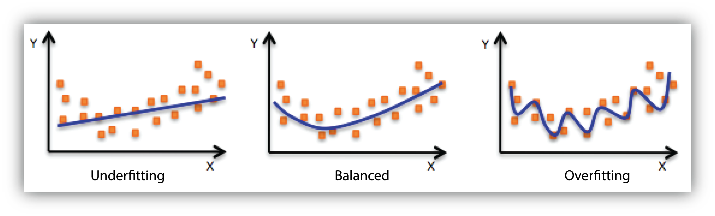

Below, we will calculate the R squared, MAE and RMSE scores and discuss whether they are overfitted, underfitted or balanced.

In [45]:
# R_squared for training dataset
model.score(X_train, y_train)

0.8582959744536787

In [46]:
# R_squared for test dataset
model.score(X_test, y_test)

0.8628896236791446

In [47]:
# MAE for train dataset
y_train_estimation = model.predict(X_train)
mean_absolute_error(y_train, y_train_estimation)

893.6618596262747

In [48]:
# MAE for test dataset
mean_absolute_error(y_test, y_predicted)

880.7236831894921

In [49]:
# RMSE for train dataset
root_mean_squared_error(y_train, y_train_estimation)

1503.0421439359907

In [50]:
# RMSE for test dataset
root_mean_squared_error(y_test, y_predicted)

1472.1179887156538

### K-fold Cross Validation

Due to the randomness, different samples can have different scores. In order to get a more general value of the score and avoid the bias from the randomness we can perform  K-fold Cross Validation.

In this image, the two colours represent data split into training and validation sets. The blue bars represent the training set, and the yellow bars represent the validation set. Validation accuracies, like 93% in Round 1, indicate model performance for each round. The model's overall performance is represented as the average accuracy across all rounds.

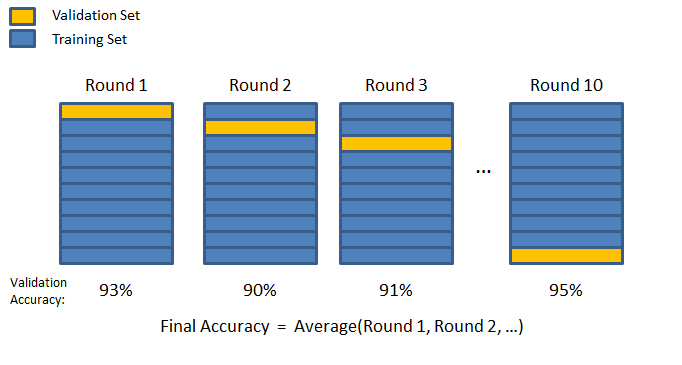

We can see this in action by importing `cross_val_score` from sklearn.

In [51]:
from sklearn.model_selection import KFold, cross_val_score

Then we can run cross validation on the model, specifying the model we created earlier, the features, and target. We also use `cv = 5` to specify we are splitting the data in to 5 subsets and `scoring = 'r2'` indicated we are using the R squared metric to evaluate model performance. We can then print the R squared scores for the 5 validation folds, as well as the mean and the standard deviation of the scores.

In [ ]:
# run cross validation on the model
kf = KFold(n_splits=5, shuffle=True, random_state=2023)
 
scores = cross_val_score(model, X, y, cv = kf, scoring = 'r2')

In [53]:
print(scores)
print('Mean:', scores.mean())
print('Standard deviation:', scores.std())

[0.86288962 0.856606   0.85829418 0.86088562 0.85577327]
Mean: 0.8588897390993253
Standard deviation: 0.002655753952893871


We have a mean of 0.86 - this indicates that our model is performing well. When we do this validation, we are aiming for a mean that is the general score of the model rather than a score for a specific set. The low standard deviation also shows the model's consistency.

##### Task 5: Validate the car model.
- Perform the cross validation and check for the model stability.
- Change the `cv` value to 3 for both the diamonds and cars models. What do you notice?